# Exploring a joint-block retrieval results file

This notebook opens one `.pkl` produced by `scripts/gd_joint_block_whole_slit_sweep.py`
(directly, or via `scripts/gd_joint_block_matrix.py`'s sweep launcher) and walks through
what's actually inside it, one level at a time, plotting as it goes.

It intentionally does **not** re-run any radiative transfer -- everything plotted here
comes straight out of the saved file. See `docs/PROJECT_STATUS.md` Sec.7 for the full
narrative this notebook's plots are drawn from (native-resolution error analysis, the
degrees-of-freedom/averaging-kernel work, the albedo patch-boundary findings).

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path("/scratch/scrowel3_lab/geocarb_simulator")
sys.path.insert(0, str(REPO_ROOT))

from geocarb_gert import along_slit_scene as als
from geocarb_gert.along_slit_state import stack_windows_along_slit
from geocarb_gert.instrument import GEOCARB_BANDS

plt.rcParams.update({
    "font.family": "serif", "font.size": 10.5,
    "axes.edgecolor": "#3a3a3a", "axes.labelcolor": "#20242b", "text.color": "#20242b",
    "xtick.color": "#3a3a3a", "ytick.color": "#3a3a3a", "axes.linewidth": 0.8,
})

## 1. Pick a results file

Point `PKL_PATH` at any single-config `.pkl` under `results/config_matrix/<tag>/results/`
(or a plain `--out` from a direct `gd_joint_block_whole_slit_sweep.py` run). The default
below is one config from the first albedo-in-state-vector sweep
(`docs/PROJECT_STATUS.md` Sec.7.3).

In [2]:
PKL_PATH = REPO_ROOT / "results/config_matrix/retrieval_prior_albedo_exact_v1/results/co2p_albedo-58-g1-ad16_analytic.pkl"

with open(PKL_PATH, "rb") as f:
    payload = pickle.load(f)

print(f"loaded {PKL_PATH.name}")
print(f"{len(payload['results'])} windows")

loaded co2p_albedo-58-g1-ad16_analytic.pkl
58 windows


## 2. Run-wide metadata

The top level of the payload is every CLI flag that could affect the run, saved so the
file is self-describing without needing the command that produced it -- `free` (which
state rows were jointly retrieved), `g_ratio`/`anchor_density` (the two resolution
knobs -- see Sec.7.6 for why they control genuinely different things), `prior_fields`
(what the prior assumed), `vary_albedo`/`overlap`/`prior_form` (the newer knobs from
Sec.6-7).

In [3]:
_skip = {"results", "tiles"}
for k, v in payload.items():
    if k not in _skip:
        print(f"{k:22s} = {v}")

fpa                    = 2
uniform                = False
barcode                = False
realistic_barcode      = False
barcode_bars           = None
uniform_priors         = False
gamma                  = 3.0
sigma_abs              = 0.1
g_ratio                = 1.0
min_window             = 4
pad                    = 4
hires_only             = True
anchor_density         = 16
state_interp           = linear
free                   = ('co2_ppm', 'p_surface_hpa', 'albedo')
corr_length            = None
prior_form             = exponential
jacobian               = analytic
n_windows              = 58
window_scale           = 1.0000000000000004
prior_fields           = exact
n_lookup_samples       = 400
prior_anchor_density   = None
flat_sy_inv            = False
overlap                = 2
vary_albedo            = True


## 3. What's inside one window

Each window is one independently-solved neighborhood of detector rows. Its own `hires`
solve carries the packed state vector `x`, the posterior covariance `cov`, and -- the
important part -- `params`, a record of *every* state row (frozen ones included) at its
own native bin positions. A bin's `values` entry is not an average over some footprint;
the forward model treats it as one node of a piecewise-linear function, and that's the
only way it's rigorous to interpret it (`docs/PROJECT_STATUS.md` Sec.7.4).

In [4]:
example_window = next(iter(payload["results"].values()))
print(f"rows {example_window['row_lo']}-{example_window['row_hi']}, G={example_window['G']} bins\n")

h = example_window["hires"]
print("free rows this solve:", h["free_names"])
print("n_free:", h["n_free"])
print("packed slices:", h["slices"])
print("has averaging kernel (avk/dof):", "avk" in h)
print()
for name, rec in h["params"].items():
    print(f"  {name:18s} free={rec['free']!s:5s} n_bins={len(np.atleast_1d(rec['positions']))} "
         f"kind={rec['kind']}")

rows 0-10, G=11 bins

free rows this solve: ['co2_ppm', 'p_surface_hpa', 'albedo']
n_free: 53
packed slices: {'co2_ppm': (0, 11), 'p_surface_hpa': (11, 22), 'albedo': (22, 53)}
has averaging kernel (avk/dof): False

  co2_ppm            free=True  n_bins=11 kind=scale
  ch4_ppb            free=False n_bins=11 kind=scale
  co_ppb             free=False n_bins=11 kind=scale
  h2o_surface_vmr    free=False n_bins=11 kind=scale
  p_surface_hpa      free=True  n_bins=11 kind=scale
  albedo             free=True  n_bins=31 kind=scale


## 4. The native, uninterpolated state along the whole slit

`gd_joint_block_matrix.py`'s own `REPORT.md` numbers interpolate every window's bins onto
a fixed 1024-row grid before scoring -- convenient for a single summary number, but it
mixes real retrieval error with row-interpolation smearing (worst at coarse `g_ratio`,
Sec.7.4). `stack_windows_along_slit` skips that step entirely: it concatenates every
window's own bins, at their own positions, with their real (block-diagonal) joint
covariance -- nothing invented, nothing smoothed.

In [5]:
FPA = payload["fpa"]
BAND_LABEL = GEOCARB_BANDS[FPA][0]
free_names = payload["free"]

stacks = {name: stack_windows_along_slit(list(payload["results"].values()), name)
         for name in free_names}
for name, st in stacks.items():
    print(f"{name:18s} {len(st.eta):5d} native bins across the whole slit")

co2_ppm             1252 native bins across the whole slit
p_surface_hpa       1252 native bins across the whole slit
albedo              3640 native bins across the whole slit


## 5. Retrieved value vs. truth, along the slit

One panel per jointly-free row. The solid line is the retrieved value at each bin's own
native position; the shaded band is ±1σ from the posterior covariance's own diagonal
(`stack.cov`, already converted to physical units); the dashed line is the true field
the scene was actually rendered with -- evaluated *exactly* at each bin's own position,
no interpolation needed on the truth side either, since it's a known closed-form
function (`als.STATE_FIELDS`/`als.SURFACE_FIELDS`).

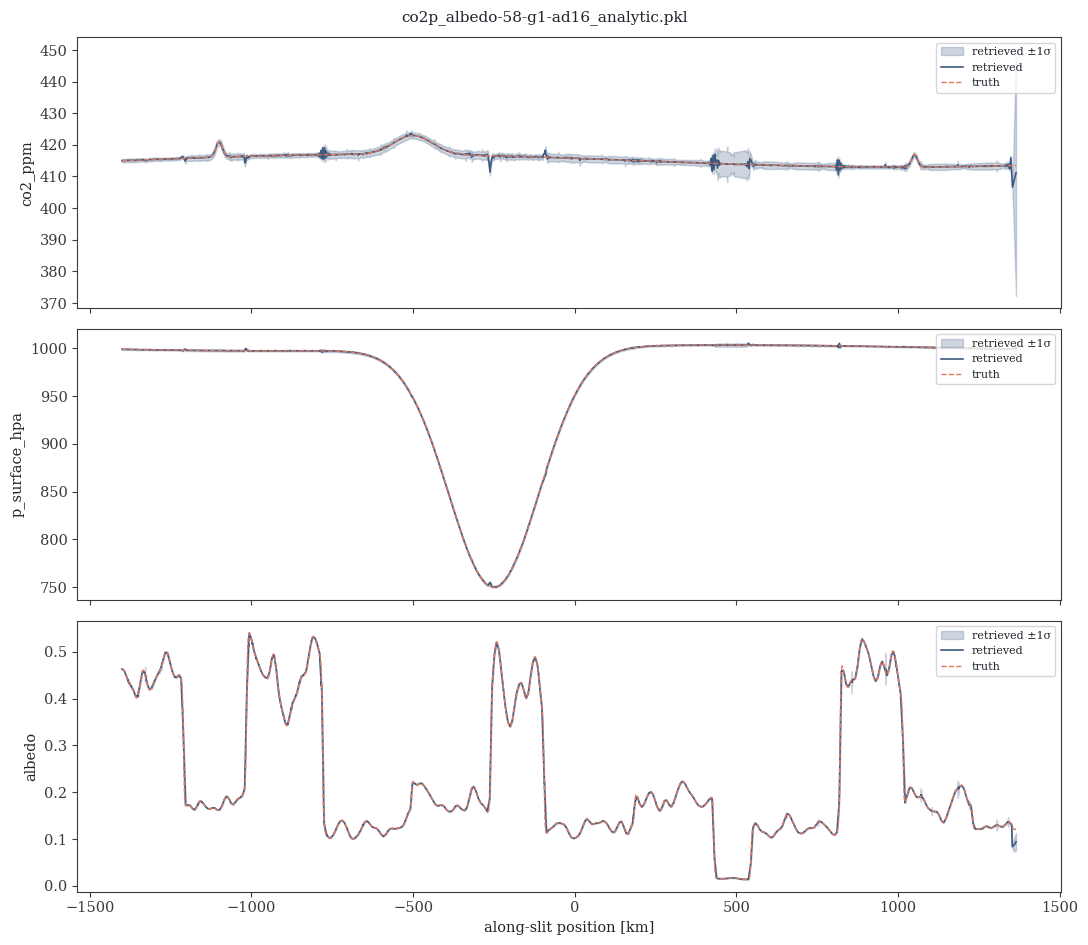

In [6]:
def truth_for(name, x_km):
    if name in als.STATE_FIELDS:
        return als.STATE_FIELDS[name](x_km)
    if name in als.SURFACE_FIELDS:
        return als.SURFACE_FIELDS[name](x_km, BAND_LABEL)
    raise KeyError(f"no truth generator registered for {name!r}")

fig, axes = plt.subplots(len(stacks), 1, figsize=(11, 3.2 * len(stacks)), sharex=True)
axes = np.atleast_1d(axes)

for ax, (name, st) in zip(axes, stacks.items()):
    x_km = st.eta * als.SLIT_HALF_KM
    order = np.argsort(x_km)
    x_km, values = x_km[order], st.values[order]
    sigma = np.sqrt(np.diag(st.cov))[order]
    truth = truth_for(name, x_km)

    ax.fill_between(x_km, values - sigma, values + sigma, color="#3D5A80", alpha=0.25,
                    label="retrieved ±1σ")
    ax.plot(x_km, values, color="#3D5A80", lw=1.2, label="retrieved")
    ax.plot(x_km, truth, color="#E07A5F", lw=1.0, ls="--", label="truth")
    ax.set_ylabel(name)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("along-slit position [km]")
fig.suptitle(PKL_PATH.name, fontsize=11)
fig.tight_layout()
plt.show()

## 6. Fit quality: residuals per window

`resid_rms` is each window's own RMS of (real data - model), in radiance units -- a
window with poor conditioning (too few bins for how many jointly-free rows it's
carrying, Sec.7.3/7.5) shows up here as elevated residual even *before* comparing
anything to truth.

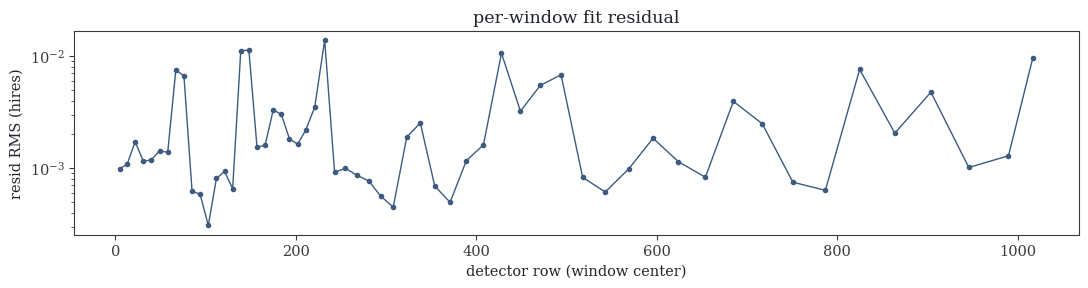

In [7]:
rows_ = []
for w in payload["results"].values():
    if "error" in w:
        continue
    x_center = 0.5 * (w["row_lo"] + w["row_hi"])
    rows_.append((x_center, w["hires"]["resid_rms"]))
rows_.sort()
centers, resid = zip(*rows_)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(centers, resid, marker="o", ms=3, lw=1, color="#3D5A80")
ax.set_yscale("log")
ax.set_xlabel("detector row (window center)")
ax.set_ylabel("resid RMS (hires)")
ax.set_title("per-window fit residual")
fig.tight_layout()
plt.show()

## 7. Degrees of freedom (averaging kernel)

`dof = trace(averaging kernel)` for a window's whole solve -- `dof / n_free` is the
fraction of that solve's free parameters actually being informed by data rather than
just reflecting the prior (0 = fully prior-dominated, 1 = fully data-dominated). Only
present in files generated after `gauss_newton_state(..., return_avk=True)` was wired
into the sweep script (`docs/PROJECT_STATUS.md` Sec.7.10) -- this cell skips gracefully
on an older file.

In [8]:
has_dof = all("dof" in w["hires"] for w in payload["results"].values() if "error" not in w)

if not has_dof:
    print("This file predates return_avk -- no dof/avk saved. Rerun the sweep to get this plot.")
else:
    rows_ = []
    for w in payload["results"].values():
        if "error" in w:
            continue
        x_center = 0.5 * (w["row_lo"] + w["row_hi"])
        h = w["hires"]
        rows_.append((x_center, h["dof"] / h["n_free"]))
    rows_.sort()
    centers, dof_frac = zip(*rows_)

    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(centers, dof_frac, marker="o", ms=3, lw=1, color="#3D5A80")
    ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("detector row (window center)")
    ax.set_ylabel("dof / n_free")
    ax.set_title("degrees-of-freedom-for-signal fraction per window")
    fig.tight_layout()
    plt.show()

This file predates return_avk -- no dof/avk saved. Rerun the sweep to get this plot.


## Where to go from here

- `docs/PROJECT_STATUS.md` Sec.7 -- the full narrative: three real bugs found building
  the albedo feature, the DOF-collapse at coarse `g_ratio`, why `anchor_density` is a
  stepping-bias fix and not noise averaging, the patch-boundary error analysis, and the
  jump-magnitude/sign relationship.
- `geocarb_gert/along_slit_state.py` -- builds the native, uninterpolated state used
  throughout this notebook.
- `geocarb_gert/along_slit_query.py` -- projects that state onto an arbitrary grid with
  a full (not diagonal-only) covariance, for when overlapping windows (`overlap>0`) need
  merging into one reported curve.
- `scripts/gd_joint_block_matrix.py` -- the sweep runner/scorer this file came from;
  `REPORT.md` in the same directory as this `.pkl` has the row-interpolated summary
  numbers this notebook's native-resolution plots are meant to be compared against.